# Exploring the Battery Storage Environment

This notebook compares different control strategies for the battery scheduling problem:
- **Heuristic**: Simple rule — charge when cheap, discharge when expensive
- **MPC**: Model Predictive Control — solves a small optimization each step
- **LP**: Linear Programming — globally optimal with perfect foresight
- **PPO**: Reinforcement Learning agent trained via Proximal Policy Optimization

**Level 1 vs Level 2:** Set `ENABLE_DEGRADATION = False` for Level 1 (no battery wear),
then change to `True` and rerun to see how degradation changes the results.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))
sys.path.insert(0, str(project_root / "01_workshop"))

import numpy as np
import matplotlib.pyplot as plt
from battery_env_solution_David import BatteryStorageEnv
from baselines import make_heuristic_policy, make_lp_policy, make_mpc_policy
from utils import run_episode, plot_episode, LiveEvalCallback

# === Configuration ===
EPISODE_LENGTH = 730           # 1 month episodes (730 hours)
ENABLE_DEGRADATION = True     # False = Level 1, True = Level 2

## 1. Environment Overview

In [2]:
env = BatteryStorageEnv(
    episode_length=EPISODE_LENGTH,
    enable_degradation=ENABLE_DEGRADATION,
)

print("=== Battery Storage Environment ===")
print(f"Capacity:        {env.capacity} kWh")
print(f"Max charge rate: {env.max_charge_rate} kW")
print(f"Episode length:  {env.episode_length} steps")
print(f"Degradation:     {env.enable_degradation}")
print(f"Action space:    {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"\nData: {env.n_episodes} total episodes, available: {env._available_episodes}")

=== Battery Storage Environment ===
Capacity:        10.0 kWh
Max charge rate: 2.5 kW
Episode length:  730 steps
Degradation:     True
Action space:    Box(-1.0, 1.0, (1,), float32)
Observation space: Box(0.0, 1.0, (13,), float32)

Data: 120 total episodes, available: (0, 96)


## 2. Baseline Policy Comparison

Compare simple policies before training any RL agent. The **baseline cost** is what you'd pay without a battery (just buying everything from the grid).

In [3]:
# "No battery" baseline cost: computed directly from price * load data
start, end = env._available_episodes
baseline_cost = np.mean(np.sum(env.prices[start:end] * env.loads[start:end], axis=1))

# Create baseline policies
policies = {
    "No battery":  "do_nothing",
    "Random":      "random",
    "Heuristic":   make_heuristic_policy(env),
    "MPC (H=4)":   make_mpc_policy(env, horizon=4),
    "LP (optimal)": make_lp_policy(env),
}

# Run 10 episodes per policy and compare costs
print(f"Baseline cost (no battery): {baseline_cost:.2f} €")
print()
print("Policy Comparison (10 episodes each):")
print("=" * 65)
print(f"{'Policy':<18} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>12}")
print("-" * 65)

for name, policy in policies.items():
    rewards = [run_episode(env, policy=policy, seed=s)[1] for s in range(10)]
    cost = -np.mean(rewards)
    savings = baseline_cost - cost
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {cost:>11.2f} ± {np.std(rewards):.1f} {savings:>+11.2f} {pct:>+11.1f}%")

Baseline cost (no battery): 156.78 €

Policy Comparison (10 episodes each):
Policy                Avg Cost (€)     Savings (€)  Savings (%)
-----------------------------------------------------------------
No battery              185.48 ± 33.8      -28.69       -18.3%
Random                  237.78 ± 4.2      -81.00       -51.7%
Heuristic               202.47 ± 4.3      -45.69       -29.1%
MPC (H=4)               172.87 ± 2.0      -16.08       -10.3%
LP (optimal)            144.46 ± 2.6      +12.32        +7.9%


## 3. Visualize a Policy

Plot a single episode to see how a policy behaves over time.

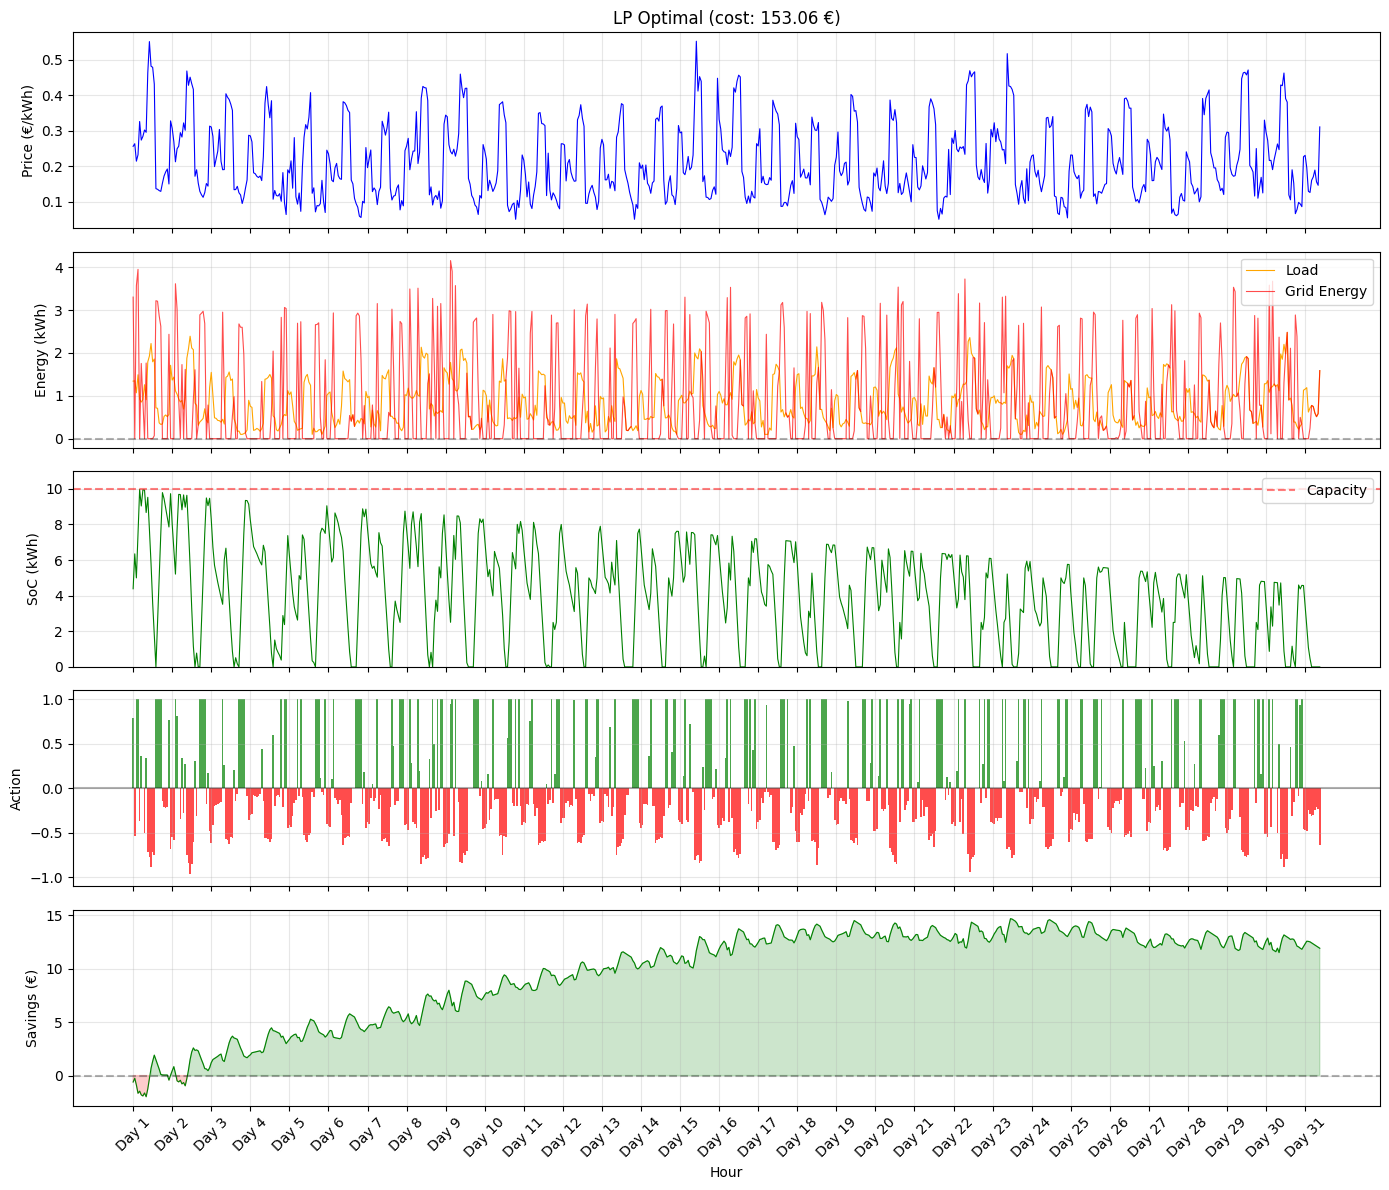

In [4]:
# Change the policy here to visualize different strategies
lp_policy = make_lp_policy(env)
data, reward = run_episode(env, policy=lp_policy, seed=42)
fig = plot_episode(data, f"LP Optimal (cost: {-reward:.2f} €)")
plt.show()

## 4. Train PPO Agent

In [5]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Train/eval split to avoid data leakage
def make_train_env():
    return BatteryStorageEnv(split="train", episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)

def make_eval_env():
    return BatteryStorageEnv(split="eval", episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)

train_env = make_vec_env(make_train_env, n_envs=4)
eval_env = make_eval_env()

print(f"Train episodes: {BatteryStorageEnv(split='train', episode_length=EPISODE_LENGTH)._available_episodes}")
print(f"Eval episodes:  {eval_env._available_episodes}")

model = PPO("MlpPolicy", train_env, verbose=0)

Train episodes: (0, 96)
Eval episodes:  (96, 120)


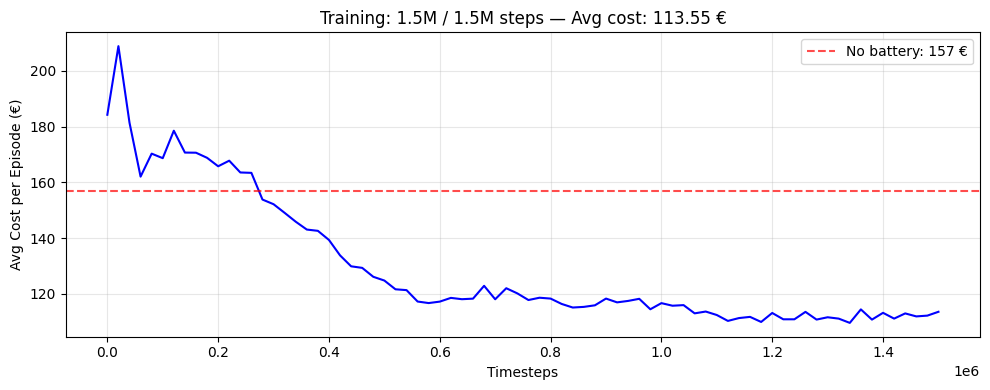


Baseline (no battery): 156.78 €
Before training:       184.25 €
After training:        113.55 €
Improvement:           43.23 € (27.6%)


In [6]:
TOTAL_TIMESTEPS = int(1.5e6)

# Baseline cost from eval data (unaffected by reward shaping)
start, end = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[start:end] * eval_env.loads[start:end], axis=1))

callback = LiveEvalCallback(
    eval_env=eval_env,
    eval_freq=20_000,
    baseline_cost=baseline_cost,
)

print(f"Training PPO for {TOTAL_TIMESTEPS/1e3:.0f}k steps...")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)

# Training summary
cost_before = -callback.mean_rewards[0]
cost_after = -callback.mean_rewards[-1]

print(f"\nBaseline (no battery): {baseline_cost:.2f} €")
print(f"Before training:       {cost_before:.2f} €")
print(f"After training:        {cost_after:.2f} €")
print(f"Improvement:           {baseline_cost - cost_after:.2f} € ({100 * (baseline_cost - cost_after) / baseline_cost:.1f}%)")

## 5. Visualize Trained PPO

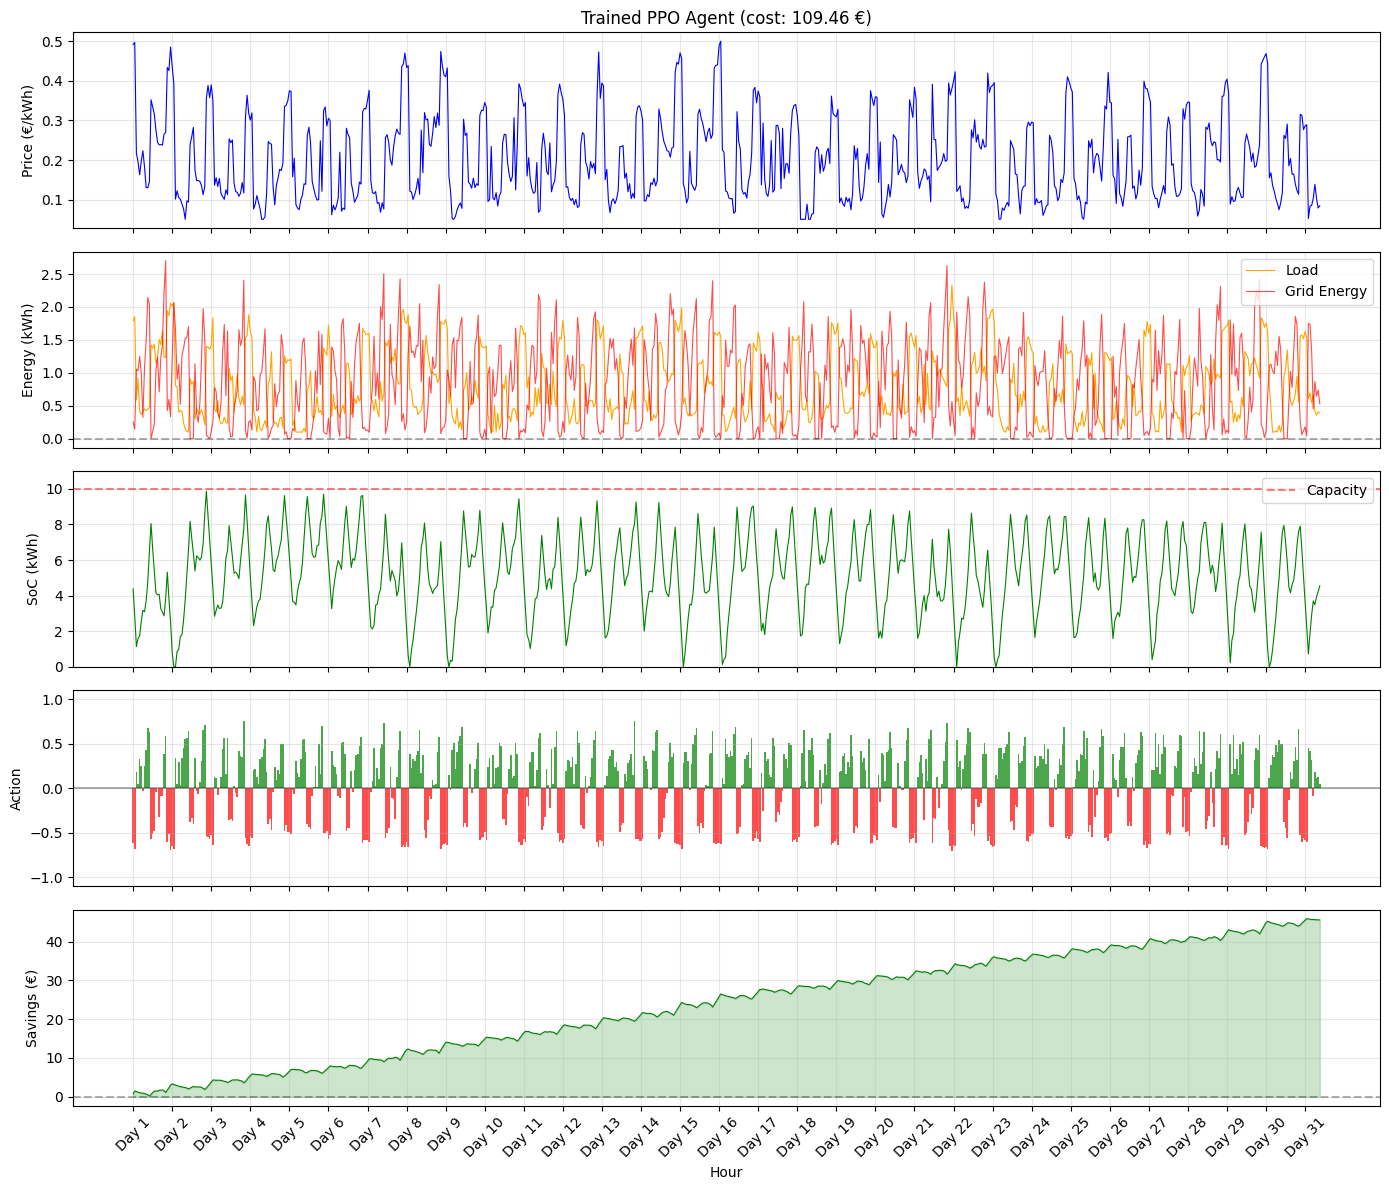

In [7]:
ppo_policy = lambda obs: model.predict(obs, deterministic=True)[0]
data_ppo, reward_ppo = run_episode(eval_env, policy=ppo_policy, seed=42)
fig = plot_episode(data_ppo, f"Trained PPO Agent (cost: {-reward_ppo:.2f} €)")
plt.show()

## 6. Final Comparison (All Policies, 100 Eval Episodes)

In [11]:
eval_env_compare = make_eval_env()

policies = {
    "No battery":   "do_nothing",
    "Heuristic":    make_heuristic_policy(eval_env_compare),
    "MPC (H=4)":    make_mpc_policy(eval_env_compare, horizon=4),
    "LP (optimal)": make_lp_policy(eval_env_compare),
    "PPO":          lambda obs: model.predict(obs, deterministic=True)[0],
}

# Baseline from eval data
start, end = eval_env_compare._available_episodes
baseline_cost = np.mean(np.sum(eval_env_compare.prices[start:end] * eval_env_compare.loads[start:end], axis=1))

results = {}
for name, policy in policies.items():
    rewards = [run_episode(eval_env_compare, policy=policy, seed=s)[1] for s in range(100)]
    results[name] = {"cost": -np.mean(rewards), "std": np.std(rewards)}

print(f"Baseline cost (no battery): {baseline_cost:.2f} €")
print()
print("Final Comparison (100 eval episodes)")
print("=" * 65)
print(f"{'Policy':<18} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>12}")
print("-" * 65)
for name, r in results.items():
    savings = baseline_cost - r["cost"]
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {r['cost']:>11.1f} ± {r['std']:.1f} {savings:>+11.1f} {pct:>+11.1f}%")

eval_env_compare.close()

Baseline cost (no battery): 156.78 €

Final Comparison (100 eval episodes)
Policy                Avg Cost (€)     Savings (€)  Savings (%)
-----------------------------------------------------------------
No battery               181.0 ± 33.1       -24.2       -15.5%
Heuristic                200.9 ± 4.0       -44.2       -28.2%
MPC (H=4)                172.5 ± 3.7       -15.8       -10.1%
LP (optimal)             143.8 ± 3.7       +13.0        +8.3%
PPO                      111.0 ± 3.3       +45.8       +29.2%


In [9]:
# Cleanup
train_env.close()
eval_env.close()